In [1]:
from src.data.dataloader import get_dataloaders

train_loader, val_loader = get_dataloaders(data_dir="src/data/RRDataset_final", batch_size=64)

# Grab one batch
sample = next(iter(train_loader))

print(f"Images shape: {sample[0].shape}")       # Should be [32, 3, 224, 224]
print(f"Real/Fake labels: {sample[1]}")      # Should be a mix of 0s and 1s
print(f"Transform labels: {sample[2]}")   # Should be a mix of 0s, 1s, and 2s

Loaded 50994 images.
Images shape: torch.Size([64, 3, 224, 224])
Real/Fake labels: tensor([0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0,
        0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1,
        0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1])
Transform labels: tensor([1, 0, 0, 2, 0, 0, 1, 0, 1, 0, 0, 2, 1, 2, 2, 1, 0, 1, 2, 2, 0, 0, 2, 2,
        0, 2, 0, 2, 1, 2, 1, 0, 2, 0, 1, 0, 1, 1, 1, 2, 2, 1, 0, 2, 0, 1, 0, 0,
        2, 0, 2, 0, 1, 2, 0, 0, 1, 2, 2, 0, 2, 2, 1, 0])


In [2]:
import torch
from torch.utils.data import DataLoader, TensorDataset

# Import your custom modules directly from the src directory
from src.train.loss import MultiTaskLoss
from src.train.loops import MultiTaskModel, train_epoch
from src.train.ablation import run_ablation_study

# Set device to GPU if available
device = torch.device(
    "cuda" if torch.cuda.is_available() 
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
    )
print(f"Using device: {device}")

Using device: cuda


In [ ]:
print("Starting Ablation Study Runs...")
# This will execute the run_ablation_study() function from your module
run_ablation_study(train_loader, val_loader)

Starting Ablation Study Runs...

--- Running iteration with Alpha=1.0, Beta=0.0 ---
Epoch [1/10] - Train Loss: 0.1613, Val Loss: 0.0701
Saving improved model to models/model_10_00.pth...
Epoch [2/10] - Train Loss: 0.0308, Val Loss: 0.0432
Saving improved model to models/model_10_00.pth...
Epoch [3/10] - Train Loss: 0.0180, Val Loss: 0.0475
No improvement. Patience: 1/3
Epoch [4/10] - Train Loss: 0.0139, Val Loss: 0.0361
Saving improved model to models/model_10_00.pth...
Epoch [5/10] - Train Loss: 0.0124, Val Loss: 0.0419
No improvement. Patience: 1/3
Epoch [6/10] - Train Loss: 0.0131, Val Loss: 0.0383
No improvement. Patience: 2/3
Epoch [7/10] - Train Loss: 0.0088, Val Loss: 0.0324
Saving improved model to models/model_10_00.pth...
Epoch [8/10] - Train Loss: 0.0147, Val Loss: 0.0495
No improvement. Patience: 1/3
Epoch [9/10] - Train Loss: 0.0095, Val Loss: 0.0402
No improvement. Patience: 2/3
Epoch [10/10] - Train Loss: 0.0090, Val Loss: 0.0716
No improvement. Patience: 3/3
Early stopp

Running evaluation on validation set...


/usr/local/Caskroom/miniconda/base/envs/deepfake/lib/python3.11/site-packages/PIL/Image.py:3574: DecompressionBombWarning: Image size (109721600 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(



--- Final Results ---
Overall Real/Fake Accuracy:   97.93%
Overall Transform Accuracy:   94.45%


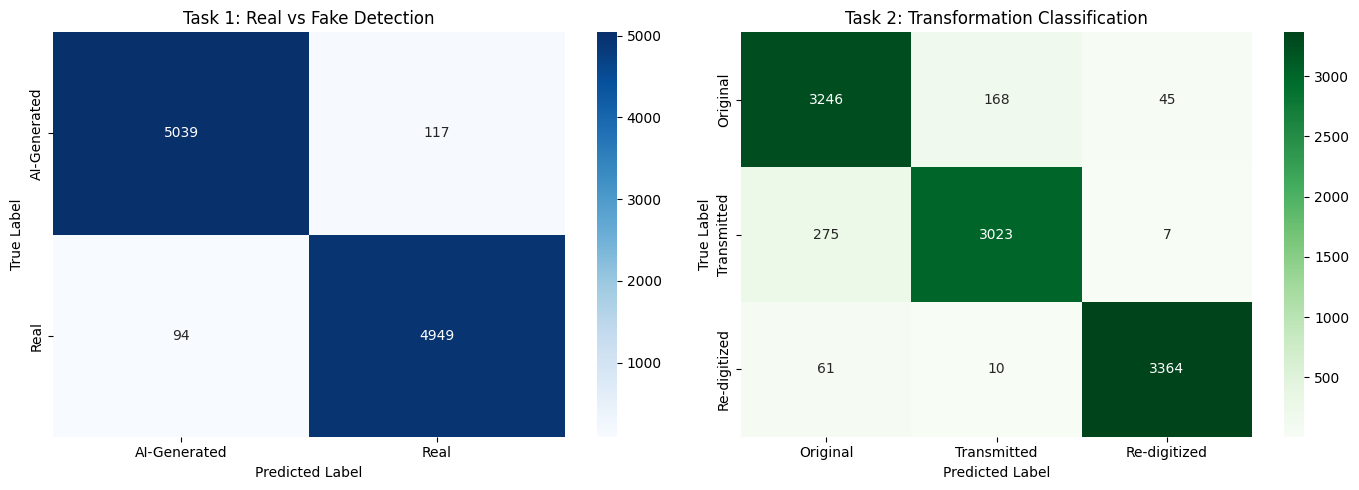

Saved: confusion_matrices.png


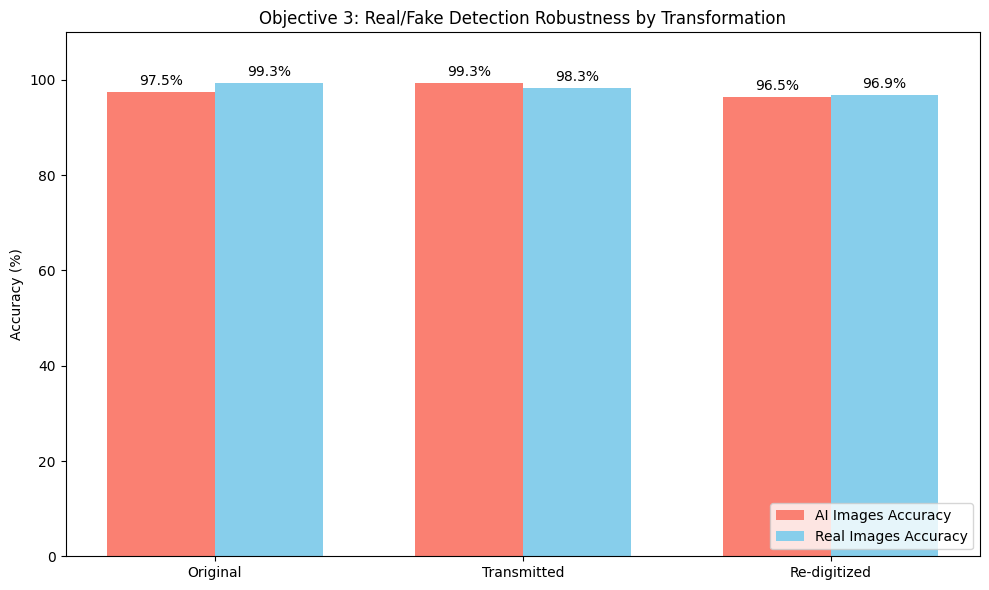

Saved: accuracy_breakdown.png
Grading 1.0_0.0...
Running evaluation on validation set...


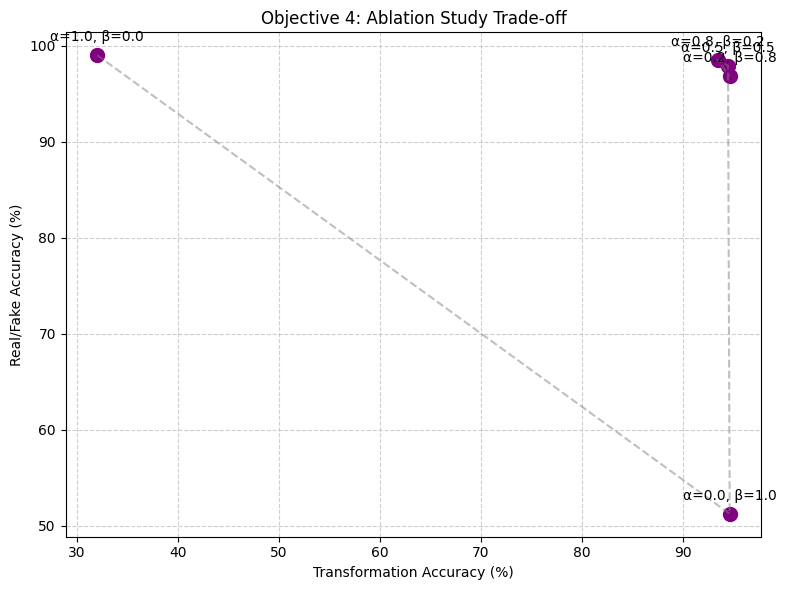

Saved: ablation_study.png


In [ ]:
import torch
from src.train.loops import MultiTaskModel
from src.evaluation.visualizer import evaluate_model, plot_ablation_study

best_model = MultiTaskModel().to(device)

best_model.load_state_dict(torch.load("models/model_05_05.pth", map_location=device))

evaluate_model(best_model, val_loader, device)

# Plot the ablation study
model_files = {
    '1.0_0.0': 'models/model_10_00.pth',
    '0.0_1.0': 'models/model_00_10.pth',
    '0.5_0.5': 'models/model_05_05.pth',
    '0.8_0.2': 'models/model_08_02.pth',
    '0.2_0.8': 'models/model_02_08.pth'
}

real_ablation_results = {}

for weight_key, file_path in model_files.items():
    print(f"Grading {weight_key}...")
    
    # Load each saved model one by one
    temp_model = MultiTaskModel().to(device)
    temp_model.load_state_dict(torch.load(file_path, map_location=device))
    
    # Run the validation loop to get the real accuracies
    acc_rf, acc_trans = evaluate_model(temp_model, val_loader, device, quiet_mode=True) 
    
    # Save to your dictionary automatically
    real_ablation_results[weight_key] = (acc_rf * 100, acc_trans * 100)

# 5. Draw the final graph using your real data!
# plot_ablation_study(real_ablation_results)

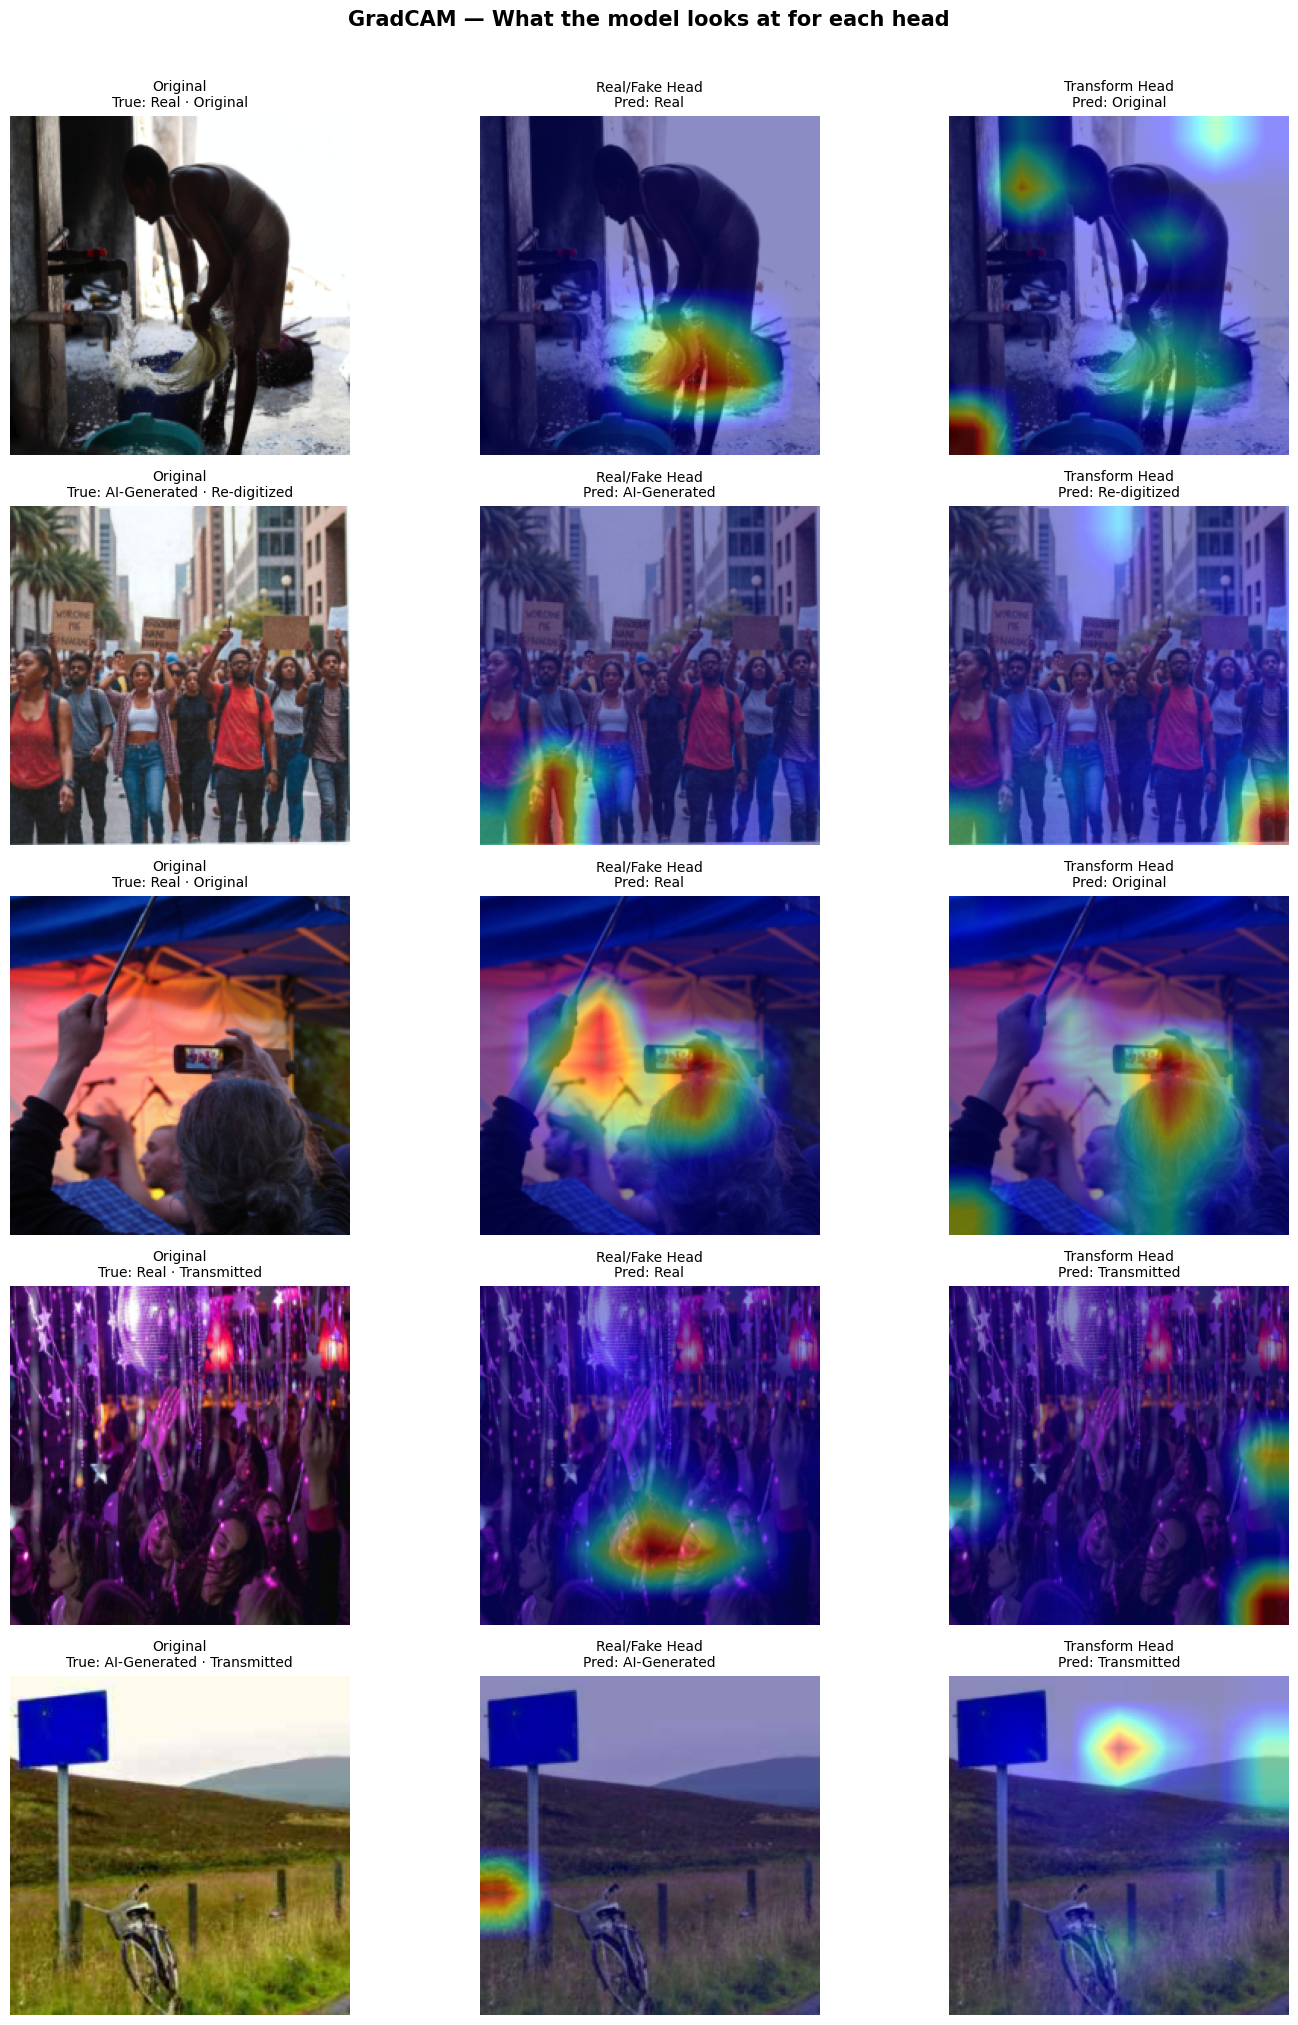

Saved: gradcam_visualization.png


In [3]:
from src.evaluation.visualizer import plot_gradcam

best_model = MultiTaskModel().to(device)

best_model.load_state_dict(torch.load("models/model_05_05.pth", map_location=device))

# best_model, val_loader, and device must already be defined
# (run the cell above first if you have not already).
plot_gradcam(best_model, val_loader, device, num_samples=5)